### Libraries

In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

### Data Preprocessing

In [2]:
#Loading File
df = pd.read_csv("credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
#Shape-Columns
print(f"Shape: {df.shape}")
print(f"Columns: {np.array(df.columns)}")

Shape: (10000, 10)
Columns: ['transaction_id' 'amount' 'transaction_hour' 'merchant_category'
 'foreign_transaction' 'location_mismatch' 'device_trust_score'
 'velocity_last_24h' 'cardholder_age' 'is_fraud']


In [4]:
#Missing Values
print(f"Missing Values:\n{df.isnull().sum()}")

Missing Values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


is_fraud
0    9849
1     151
Name: count, dtype: int64


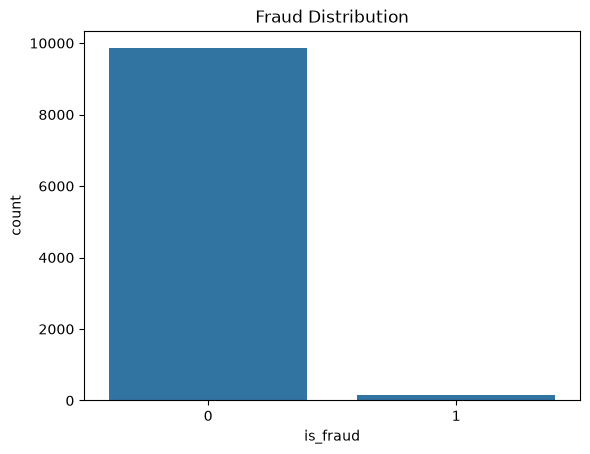

In [5]:
#Viewing Imbalance
print(df["is_fraud"].value_counts())
sns.countplot(data=df, x="is_fraud")
plt.title("Fraud Distribution")
plt.show()

### Model Training and Evaluation

In [6]:
#Feature-Target Separation
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [7]:
#One-Hot Encoding
X = pd.get_dummies(X, columns=["merchant_category"], drop_first=True)
X.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,84.47,22,0,0,66,3,40,True,False,False,False
1,2,541.82,3,1,0,87,1,64,False,False,False,True
2,3,237.01,17,0,0,49,1,61,False,False,True,False
3,4,164.33,4,0,1,72,3,34,False,False,True,False
4,5,30.53,15,0,0,79,0,44,False,True,False,False


In [8]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#Filling Imbalance
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE")
print(y_train.value_counts())

print("After SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
is_fraud
0    7879
1     121
Name: count, dtype: int64
After SMOTE
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [10]:
#Model Training
model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
model.fit(X_train_smote, y_train_smote)

C:\Users\shaur\miniconda3\envs\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [11]:
#Model Evaluation
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.979
ROC-AUC Score: 0.8908629441624366
Confusion Matrix:
[[1934   36]
 [   6   24]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.40      0.80      0.53        30

    accuracy                           0.98      2000
   macro avg       0.70      0.89      0.76      2000
weighted avg       0.99      0.98      0.98      2000

